<a href="https://colab.research.google.com/github/kholoud400/ML-NN-CNN-projects/blob/main/Skin_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Cancer Classification

This project aims to classify skin cancer images into:

- Benign
- Malignant

using Deep Learning and Transfer Learning techniques.

The project includes:
- Data preprocessing
- Data augmentation
- CNN models
- Transfer learning with MobileNetV2
- Fine-tuning
- Evaluation metrics
- Streamlit deployment

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fanconic/skin-cancer-malignant-vs-benign")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-malignant-vs-benign' dataset.
Path to dataset files: /kaggle/input/skin-cancer-malignant-vs-benign


# 1. Import Libraries

In this section we import all required libraries for:
- Deep Learning
- Visualization
- Data processing
- Evaluation
- Deployment

In [ ]:

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    GlobalAveragePooling2D,
    Input
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.applications import (
    MobileNetV2,
    EfficientNetB0
)

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

#2.Data path

In [ ]:

train_dir = path + "/train"
test_dir  = path + "/test"

IMG_SIZE = 224
BATCH_SIZE = 16

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
import os
print(path)

/kaggle/input/skin-cancer-malignant-vs-benign


# 3. Dataset Analysis

We analyze:
- Number of samples
- Class distribution
- Data balance

In [ ]:

benign_count = len(os.listdir(train_dir + "/benign"))
malignant_count = len(os.listdir(train_dir + "/malignant"))

print("Benign Images    :", benign_count)
print("Malignant Images :", malignant_count)

Benign Images    : 1440
Malignant Images : 1197


#3.2. VISUALIZE DATA DISTRIBUTION

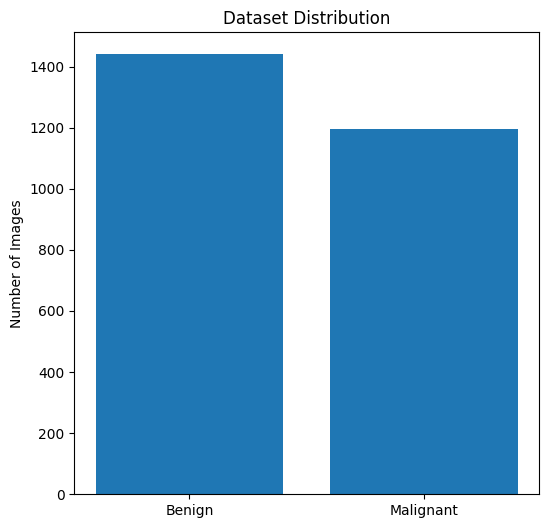

In [ ]:

classes = ["Benign", "Malignant"]
counts = [benign_count, malignant_count]

plt.figure(figsize=(6,6))
plt.bar(classes, counts)
plt.title("Dataset Distribution")
plt.ylabel("Number of Images")
plt.show()

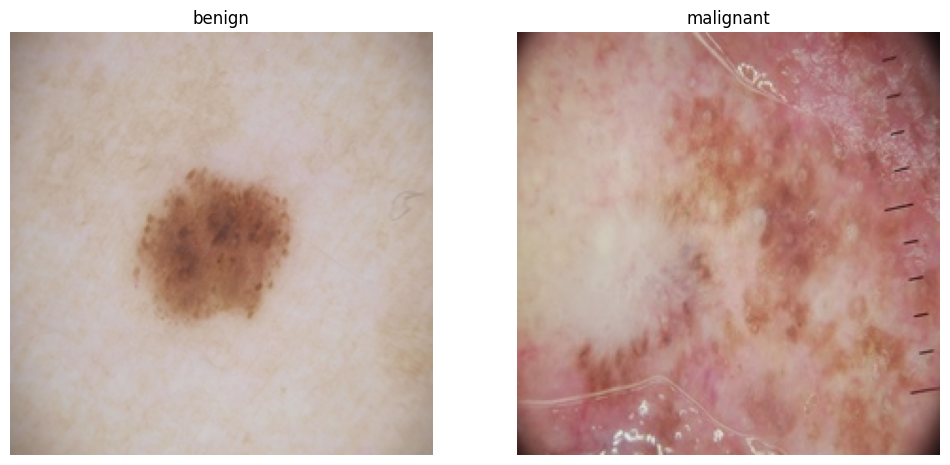

In [ ]:
import random

plt.figure(figsize=(12,6))

classes = ['benign', 'malignant']

for i, cls in enumerate(classes):

    folder = os.path.join(train_dir, cls)

    img_name = random.choice(os.listdir(folder))

    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.show()

#4. DATA PREPROCESSING + AUGMENTATION

In [ ]:

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.1
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.1
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

#4.1 TRAIN GENERATOR

In [ ]:

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

Found 2374 images belonging to 2 classes.


#4.2 VALIDATION GENERATOR

In [ ]:

valid_generator = valid_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 263 images belonging to 2 classes.


#4.3 TEST GENERATOR

In [ ]:

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 660 images belonging to 2 classes.


#4.4 SHOW SAMPLE IMAGES

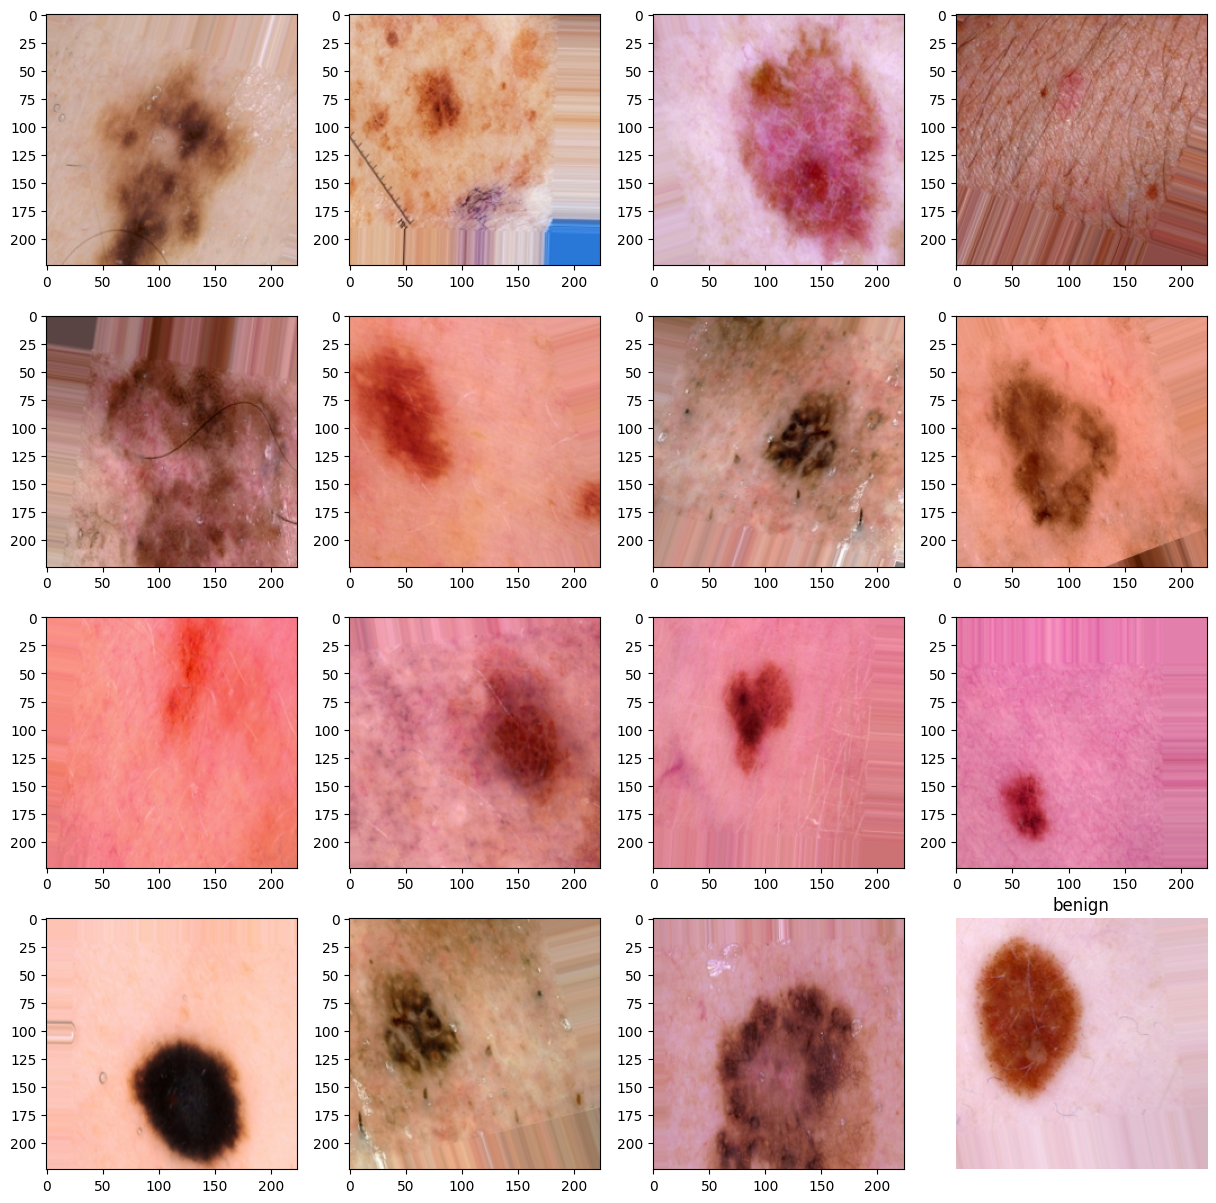

In [ ]:

class_names = list(train_generator.class_indices.keys())

X_batch, y_batch = next(train_generator)

plt.figure(figsize=(15,15))

for i in range(16):

    plt.subplot(4,4,i+1)

    img = X_batch[i]
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)

plt.title(class_names[np.argmax(y_batch[i])])

plt.axis("off")

plt.show()

# 5. CNN Model Architecture

This section builds different deep learning architectures:
- CNN from scratch
- Improved CNN
- using MobileNetV2
- EfficientNetB0
- ResNet50
- DenseNet121
- InceptionV3

#5.1 . CNN MODEL 1 (FROM SCRATCH)

In [ ]:

cnn_model_1 = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(2, activation='softmax')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 5.1.1 COMPILE MODEL 1

In [ ]:

cnn_model_1.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

cnn_model_1.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

#5.2 CNN MODEL 2 (FROM SCRATCH)

In [ ]:

cnn_model_2 = Sequential([

    Conv2D(64, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(2, activation='softmax')
])



#5.2.1 COMPILE MODEL 2

In [ ]:

cnn_model_2.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

cnn_model_2.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 438,914 (1.67 MB)

 Trainable params: 438,018 (1.67 MB)

 Non-trainable params: 896 (3.50 KB)

#5.3  MobileNetV2 model

In [ ]:

base_model = MobileNetV2(

    include_top=False,

    weights='imagenet',

    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#5.3.1 Fine Tuning

We unfreeze part of the pretrained model
to improve feature extraction and increase accuracy.

In [ ]:

base_model.trainable = False


inputs = Input(shape=(224,224,3))

x = base_model(inputs)

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = BatchNormalization()(x)

x = Dropout(0.5)(x)

x = Dense(64, activation='relu')(x)

x = Dropout(0.3)(x)

outputs = Dense(2, activation='softmax')(x)

transfer_model = Model(inputs, outputs)



#5.3.2 COMPILE MobileNetV2

In [ ]:
transfer_model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    loss='categorical_crossentropy',

    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

transfer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,603,522 (9.93 MB)

 Trainable params: 345,026 (1.32 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

# 5.4 EfficientNetB0 model

In [ ]:
efficient_base = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

efficient_base.trainable = False

inputs = Input(shape=(224,224,3))

x = efficient_base(inputs)

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = BatchNormalization()(x)

x = Dropout(0.5)(x)

outputs = Dense(2, activation='softmax')(x)

efficient_model = Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# 5.4.1 Compile EfficientNetB0

In [ ]:
efficient_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)
efficient_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,045 (16.70 MB)

 Trainable params: 328,962 (1.25 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

# 5.5 ResNet50 model

In [ ]:
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

resnet_base.trainable = False

inputs = Input(shape=(224,224,3))

x = resnet_base(inputs)

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = BatchNormalization()(x)

x = Dropout(0.5)(x)

outputs = Dense(2, activation='softmax')(x)

resnet_model = Model(inputs, outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# 5.5.1 Compile ResNet50

In [ ]:
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)
resnet_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,794 (91.99 MB)

 Trainable params: 525,570 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

# 5.6 DenseNet121 model

In [ ]:
from tensorflow.keras.applications import DenseNet121
dense_base = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

dense_base.trainable = False

inputs = Input(shape=(224,224,3))

x = dense_base(inputs)

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = BatchNormalization()(x)

x = Dropout(0.5)(x)

outputs = Dense(2, activation='softmax')(x)

dense_model = Model(inputs, outputs)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# 5.6.1 Compile DenseNet121

In [ ]:
dense_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)
dense_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,301,442 (27.85 MB)

 Trainable params: 263,426 (1.00 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

# 5.7 InceptionV3 model

In [ ]:
from tensorflow.keras.applications import InceptionV3
inception_base = InceptionV3(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)

inception_base.trainable = False

inputs = Input(shape=(224,224,3))

x = inception_base(inputs)

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = BatchNormalization()(x)

x = Dropout(0.5)(x)

outputs = Dense(2, activation='softmax')(x)

inception_model = Model(inputs, outputs)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# 5.7.1 Compile InceptionV3

In [ ]:
inception_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)
inception_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_101         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,328,866 (85.18 MB)

 Trainable params: 525,570 (2.00 MB)

 Non-trainable params: 21,803,296 (83.17 MB)

# 6.Callbacks

In this section, we use different callbacks to improve model training efficiency and performance stability.

Callbacks help us:
- Monitor validation loss during training
- Automatically save the best-performing model
- Reduce learning rate when performance plateaus
- Stop training early to avoid overfitting

This ensures that the model generalizes better on unseen data.

In [ ]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=5,
    min_lr=1e-6
)

callbacks = [early_stop, checkpoint, reduce_lr]



# Model Fitting
In this stage, the models were trained using the training dataset and validated using the validation dataset by applying the fit() function.

#

# MobileNetV2 Model fit

In [ ]:

history = transfer_model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=15,

    callbacks=callbacks
)



Epoch 1/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 125s 794ms/step - accuracy: 0.7687 - loss: 0.5301 - precision_10: 0.7687 - recall_10: 0.7687 - val_accuracy: 0.8175 - val_loss: 0.4514 - val_precision_10: 0.8175 - val_recall_10: 0.8175 - learning_rate: 0.0010
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 118s 788ms/step - accuracy: 0.8130 - loss: 0.4294 - precision_10: 0.8130 - recall_10: 0.8130 - val_accuracy: 0.7833 - val_loss: 0.5213 - val_precision_10: 0.7833 - val_recall_10: 0.7833 - learning_rate: 0.0010
Epoch 3/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 115s 770ms/step - accuracy: 0.8239 - loss: 0.3759 - precision_10: 0.8239 - recall_10: 0.8239 - val_accuracy: 0.7757 - val_loss: 0.5269 - val_precision_10: 0.7757 - val_recall_10: 0.7757 - learning_rate: 0.0010
Epoch 4/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 114s 763ms/step - accuracy: 0.8382 - loss: 0.3597 - precision_10: 0.8382 - recall_10: 0.8382 - val_accuracy: 0.7376 - val_loss: 0.5171 - val_precision_10: 0.7376 - val_recall_10: 0.7376 - learning_rate: 0.0010


# Resnet Model fit

In [ ]:
history_res = resnet_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=5,
    callbacks=callbacks
)

results_res = resnet_model.evaluate(test_generator)
print("ResNet Accuracy:", results_res[1])

resnet_model.save("resnet.keras")

Epoch 1/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 441s 3s/step - accuracy: 0.7561 - loss: 0.5400 - precision_7: 0.7561 - recall_7: 0.7561 - val_accuracy: 0.5475 - val_loss: 0.7030 - val_precision_7: 0.5475 - val_recall_7: 0.5475 - learning_rate: 0.0010
Epoch 2/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 468s 3s/step - accuracy: 0.7734 - loss: 0.5067 - precision_7: 0.7734 - recall_7: 0.7734 - val_accuracy: 0.7338 - val_loss: 0.6068 - val_precision_7: 0.7338 - val_recall_7: 0.7338 - learning_rate: 0.0010
Epoch 3/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - accuracy: 0.7826 - loss: 0.4858 - precision_7: 0.7826 - recall_7: 0.7826 - val_accuracy: 0.5741 - val_loss: 0.7486 - val_precision_7: 0.5741 - val_recall_7: 0.5741 - learning_rate: 0.0010
Epoch 4/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 427s 3s/step - accuracy: 0.7763 - loss: 0.4834 - precision_7: 0.7763 - recall_7: 0.7763 - val_accuracy: 0.8251 - val_loss: 0.4645 - val_precision_7: 0.8251 - val_recall_7: 0.8251 - learning_rate: 0.0010
Epoch 5/5
149/149 ━━━━━━━━━━━━━━

# Efficient  Model fit

In [ ]:
history_eff = efficient_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=5,
    callbacks=callbacks
)

results_eff = efficient_model.evaluate(test_generator)
print("EfficientNet Accuracy:", results_eff[1])

efficient_model.save("efficient.keras")

Epoch 1/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.5337 - loss: 0.8417 - precision_6: 0.5337 - recall_6: 0.5337 - val_accuracy: 0.4525 - val_loss: 0.7180 - val_precision_6: 0.4525 - val_recall_6: 0.4525 - learning_rate: 0.0010
Epoch 2/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.5282 - loss: 0.7820 - precision_6: 0.5282 - recall_6: 0.5282 - val_accuracy: 0.4525 - val_loss: 0.8087 - val_precision_6: 0.4525 - val_recall_6: 0.4525 - learning_rate: 0.0010
Epoch 3/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.5468 - loss: 0.7326 - precision_6: 0.5468 - recall_6: 0.5468 - val_accuracy: 0.4525 - val_loss: 1.0208 - val_precision_6: 0.4525 - val_recall_6: 0.4525 - learning_rate: 0.0010
Epoch 4/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.5497 - loss: 0.7055 - precision_6: 0.5497 - recall_6: 0.5497 - val_accuracy: 0.5475 - val_loss: 0.8174 - val_precision_6: 0.5475 - val_recall_6: 0.5475 - learning_rate: 0.0010
Epoch 5/5
149/149 ━━━━━━━━━━━━━━

# Dence  Model fit

In [ ]:
history_dense = dense_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=5,
    callbacks=callbacks
)

results_dense = dense_model.evaluate(test_generator)
print("DenseNet Accuracy:", results_dense[1])

dense_model.save("dense.keras")

Epoch 1/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 428s 3s/step - accuracy: 0.7949 - loss: 0.5206 - precision_8: 0.7949 - recall_8: 0.7949 - val_accuracy: 0.7909 - val_loss: 0.4620 - val_precision_8: 0.7909 - val_recall_8: 0.7909 - learning_rate: 0.0010
Epoch 2/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 401s 3s/step - accuracy: 0.8155 - loss: 0.4219 - precision_8: 0.8155 - recall_8: 0.8155 - val_accuracy: 0.7833 - val_loss: 0.4439 - val_precision_8: 0.7833 - val_recall_8: 0.7833 - learning_rate: 0.0010
Epoch 3/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 411s 3s/step - accuracy: 0.8408 - loss: 0.3703 - precision_8: 0.8408 - recall_8: 0.8408 - val_accuracy: 0.7529 - val_loss: 0.4870 - val_precision_8: 0.7529 - val_recall_8: 0.7529 - learning_rate: 0.0010
Epoch 4/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 436s 3s/step - accuracy: 0.8526 - loss: 0.3376 - precision_8: 0.8526 - recall_8: 0.8526 - val_accuracy: 0.7643 - val_loss: 0.4484 - val_precision_8: 0.7643 - val_recall_8: 0.7643 - learning_rate: 0.0010
Epoch 5/5
149/149 ━━━━━━━━━━━━━━

# Inception  Model fit

In [ ]:
history_inc = inception_model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=5,
    callbacks=callbacks
)

results_inc = inception_model.evaluate(test_generator)
print("Inception Accuracy:", results_inc[1])

inception_model.save("inception.keras")

Epoch 1/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.7452 - loss: 0.6276 - precision_9: 0.7452 - recall_9: 0.7452 - val_accuracy: 0.7681 - val_loss: 0.5505 - val_precision_9: 0.7681 - val_recall_9: 0.7681 - learning_rate: 0.0010
Epoch 2/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.7978 - loss: 0.4540 - precision_9: 0.7978 - recall_9: 0.7978 - val_accuracy: 0.7681 - val_loss: 0.4783 - val_precision_9: 0.7681 - val_recall_9: 0.7681 - learning_rate: 0.0010
Epoch 3/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8037 - loss: 0.4316 - precision_9: 0.8037 - recall_9: 0.8037 - val_accuracy: 0.7567 - val_loss: 0.4736 - val_precision_9: 0.7567 - val_recall_9: 0.7567 - learning_rate: 0.0010
Epoch 4/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.8113 - loss: 0.4079 - precision_9: 0.8113 - recall_9: 0.8113 - val_accuracy: 0.7605 - val_loss: 0.4869 - val_precision_9: 0.7605 - val_recall_9: 0.7605 - learning_rate: 0.0010
Epoch 5/5
149/149 ━━━━━━━━━━━━━━

# Model Evaluation
After training, the performance of the models was evaluated using different evaluation metrics to measure classification accuracy and overall model performance on the test dataset.
The evaluation process included:


- Accuracy Score

- Loss and Accuracy Curves

- Confusion Matrix
- Classification Report

The best model was selected based on the evaluation results and overall performance.

#  PLOT TRAINING HISTORY

In [ ]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)




# ACCURACY

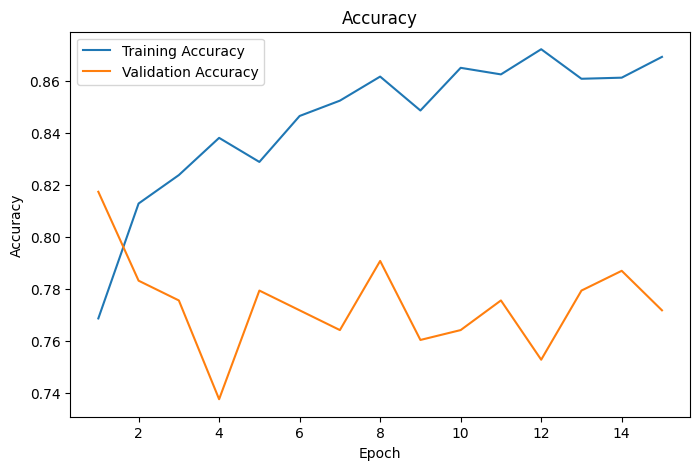

In [ ]:

plt.figure(figsize=(8,5))

plt.plot(epochs, acc, label='Training Accuracy')

plt.plot(epochs, val_acc, label='Validation Accuracy')

plt.title("Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()



#  LOSS

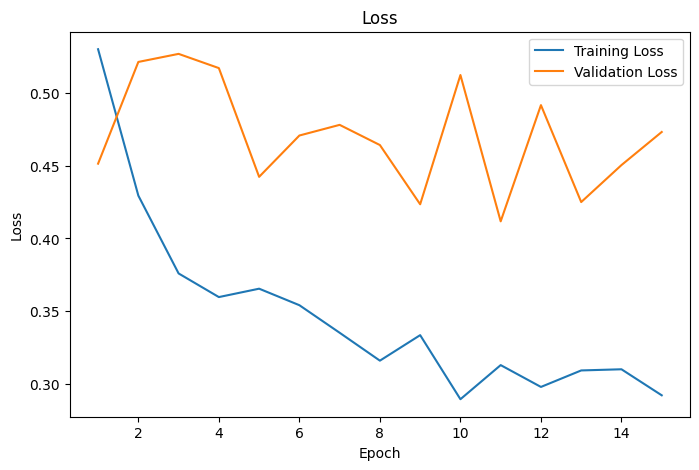

In [ ]:

plt.figure(figsize=(8,5))

plt.plot(epochs, loss, label='Training Loss')

plt.plot(epochs, val_loss, label='Validation Loss')

plt.title("Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()



In [ ]:

results = transfer_model.evaluate(test_generator)

print("\n========== TEST RESULTS ==========")

print("Loss      :", results[0])

print("Accuracy  :", results[1])

print("Precision :", results[2])

print("Recall    :", results[3])



42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 552ms/step - accuracy: 0.8424 - loss: 0.3307 - precision_10: 0.8424 - recall_10: 0.8424

========== TEST RESULTS ==========
Loss      : 0.3306766748428345
Accuracy  : 0.842424213886261
Precision : 0.842424213886261
Recall    : 0.842424213886261


In [ ]:
# =========================================================
# PREDICTIONS
# =========================================================

predictions = transfer_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.labels



42/42 ━━━━━━━━━━━━━━━━━━━━ 25s 573ms/step


In [ ]:
# =========================================================
# F1 SCORE
# =========================================================

f1 = f1_score(y_true, y_pred)

print("F1 Score :", f1)

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\n========== CLASSIFICATION REPORT ==========\n")

print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names
    )
)



F1 Score : 0.823728813559322

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

      benign       0.85      0.87      0.86       360
   malignant       0.84      0.81      0.82       300

    accuracy                           0.84       660
   macro avg       0.84      0.84      0.84       660
weighted avg       0.84      0.84      0.84       660



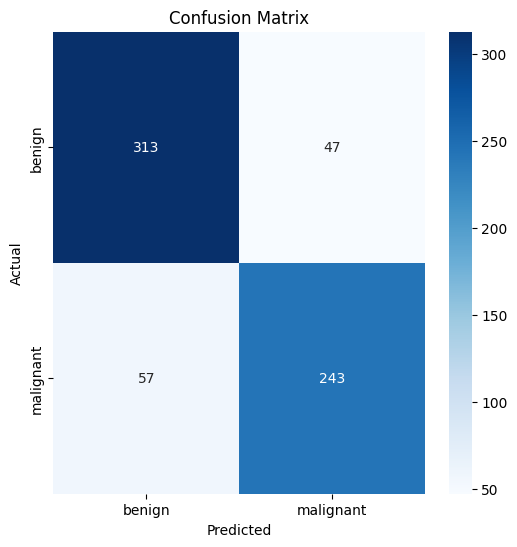

In [ ]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()



In [ ]:
# =========================================================
# 13. SAVE MODEL
# =========================================================

transfer_model.save("skin_cancer_model.keras")



In [ ]:
# =========================================================
# 14. LOAD MODEL
# =========================================================

model = tf.keras.models.load_model("skin_cancer_model.keras")



In [ ]:
# =========================================================
# 15. INFERENCE FUNCTION
# =========================================================

def predict_image(path):

    img = cv2.imread(path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (224,224))

    img = preprocess_input(img)

    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)

    class_index = np.argmax(prediction)

    classes = ['benign', 'malignant']

    confidence = np.max(prediction)

    plt.imshow(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB))

    plt.title(
        f"Prediction: {classes[class_index]} | Confidence: {confidence:.2f}"
    )

    plt.axis("off")

    plt.show()



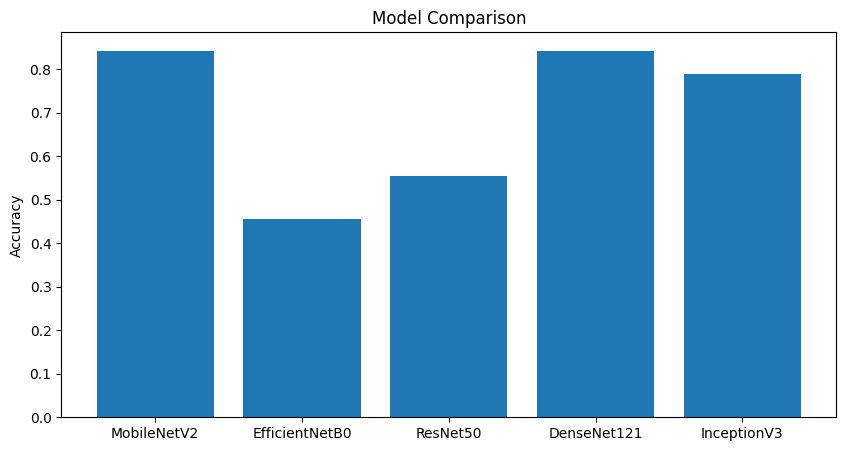

In [ ]:
model_names = [
    "MobileNetV2",
    "EfficientNetB0",
    "ResNet50",
    "DenseNet121",
    "InceptionV3"
]

accuracies = [
    results[1],
    results_eff[1],
    results_res[1],
    results_dense[1],
    results_inc[1]
]

plt.figure(figsize=(10,5))

plt.bar(model_names, accuracies)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()



In [ ]:
best_accuracy = max(accuracies)

best_model = model_names[accuracies.index(best_accuracy)]

print("Best Model:", best_model)
print("Best Accuracy:", best_accuracy)

Best Model: MobileNetV2
Best Accuracy: 0.842424213886261


In [ ]:
%%writefile app.py

Writing app.py
